# Experiment C3 — DANN: Modulation-Invariant One-Class Authenticator (v2)
**Thesis:** Lightweight Device Authentication Using RF Fingerprinting  
**Authors:** Amitha · Tharangi  |  **Supervisor:** Prof. Qinghua Wang

---

## Concept

Standard cross-entropy training entangles device identity with modulation type.
DANN forces the embedding space to be **modulation-invariant** via a
Gradient Reversal Layer (GRL) on an adversarial modulation head.

```
IQ (128×2)
    ↓
1D CNN Backbone  (conv×3 + GAP)
    ↓
Dense-64 embedding  ← forced modulation-invariant by GRL
   /              \
Device head        Modulation head (adversarial via GRL)
DEV01/DEV02        BPSK/QPSK/GFSK/OOK  ← backbone learns to fool this
```

**v2 fixes applied:**
- Fix 1: OC-SVM nu grid search (nu=0.05 too tight)
- Fix 2: ROC-sweep threshold calibration (not forced percentile)
- Fix 3: File existence check for SNR20
- Fix 4: Verbose weight transfer verification

## Section 1 — Mount Drive + Setup

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, time, warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import gc

BASE = '/content/drive/MyDrive/My Thesis'
PREPROCESSED = os.path.join(BASE, 'Preprocessed')
EXP_A_MODEL  = os.path.join(BASE, 'Models', 'ExperimentA', 'best_model_augmented.keras')
MODEL_DIR    = os.path.join(BASE, 'Models', 'ExperimentC3_DANN')
os.makedirs(MODEL_DIR, exist_ok=True)

MODULATIONS  = ['BPSK', 'QPSK', 'GFSK', 'OOK']
MOD_INDEX    = {m: i for i, m in enumerate(MODULATIONS)}
SESSIONS     = ['S1', 'S2']
AUG_TAGS     = ['clean', 'SNR10', 'SNR0']
TARGET_FAR   = 0.05
WINDOWS_CAP  = 5000
LAMBDA_GRL   = 0.5
MAX_EPOCHS   = 40
BATCH_SIZE   = 256
LR           = 1e-4
RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

results_c3 = {}

print(f'BASE     : {os.listdir(BASE)}')
print(f'Exp A    : {os.path.exists(EXP_A_MODEL)}')
print(f'TF       : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU      : {gpus[0].name if gpus else "CPU only"}')
print(f'λ_GRL={LAMBDA_GRL}  cap={WINDOWS_CAP:,}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE     : ['Literature', 'My LR Drafts', 'midway-seminar prep.pptx', 'Simulations', 'Models', 'Recordings', 'GNU Radio', 'Notebooks', 'Preprocessed']
Exp A    : True
TF       : 2.20.0
GPU      : /physical_device:GPU:0
λ_GRL=0.5  cap=5,000


## Section 2 — File Existence Check (Fix 3)

In [3]:
import os

# Check what's actually inside Preprocessed
print(os.listdir(PREPROCESSED))

# Check S2 folder name
for item in os.listdir(PREPROCESSED):
    full = os.path.join(PREPROCESSED, item)
    if os.path.isdir(full):
        print(f'\n{item}/  →  {os.listdir(full)[:4]}...')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/My Thesis (main)/Preprocessed'

In [5]:
# Check which SNR tags exist — determines EVAL_SNRS
print('Checking preprocessed file availability...')
available_tags = set()
for mod in MODULATIONS:
    for tag in ['clean', 'SNR20', 'SNR10', 'SNR0']:
        path = os.path.join(PREPROCESSED, 'S2', f'{mod}_{tag}_X.npy')
        exists = os.path.exists(path)
        if exists:
            available_tags.add(tag)
        print(f'  S2/{mod}/{tag}: {"✅" if exists else "❌ MISSING"}')

# Set evaluation SNRs based on available files
if 'SNR20' in available_tags:
    EVAL_SNRS  = [None, 20, 10, 0]
    SNR_LABELS = ['Clean', 'SNR20', 'SNR10', 'SNR0']
else:
    EVAL_SNRS  = [None, 10, 0]
    SNR_LABELS = ['Clean', 'SNR10', 'SNR0']
    print('\nSNR20 not found — evaluating at Clean/SNR10/SNR0 only')

print(f'\nEval SNRs: {EVAL_SNRS}')
print(f'SNR labels: {SNR_LABELS}')

Checking preprocessed file availability...
  S2/BPSK/clean: ✅
  S2/BPSK/SNR20: ✅
  S2/BPSK/SNR10: ✅
  S2/BPSK/SNR0: ✅
  S2/QPSK/clean: ✅
  S2/QPSK/SNR20: ✅
  S2/QPSK/SNR10: ✅
  S2/QPSK/SNR0: ✅
  S2/GFSK/clean: ✅
  S2/GFSK/SNR20: ✅
  S2/GFSK/SNR10: ✅
  S2/GFSK/SNR0: ✅
  S2/OOK/clean: ✅
  S2/OOK/SNR20: ✅
  S2/OOK/SNR10: ✅
  S2/OOK/SNR0: ✅

Eval SNRs: [None, 20, 10, 0]
SNR labels: ['Clean', 'SNR20', 'SNR10', 'SNR0']


## Section 3 — Gradient Reversal Layer + DANN Architecture

In [7]:
def gradient_reversal(x, lambda_val):
    @tf.custom_gradient
    def _inner(x):
        def grad(dy):
            return -lambda_val * dy
        return tf.identity(x), grad
    return _inner(x)

class GradientReversalLayer(tf.keras.layers.Layer):
    def __init__(self, lambda_val=1.0, **kwargs):
        super().__init__(**kwargs)
        # tf.Variable so the λ schedule callback can update it during training
        self.lambda_val = tf.Variable(float(lambda_val), trainable=False, dtype=tf.float32)
    def call(self, x):
        return gradient_reversal(x, self.lambda_val)
    def get_config(self):
        cfg = super().get_config()
        cfg['lambda_val'] = float(self.lambda_val.numpy())
        return cfg


def build_dann(lambda_val=0.5, n_devices=2, n_mods=4):
    iq_input  = keras.Input(shape=(128, 2), name='iq_input')
    x = layers.Conv1D(32, 7, padding='same', activation='relu', name='conv1')(iq_input)
    x = layers.AveragePooling1D(2, name='pool1')(x)
    x = layers.Conv1D(64, 5, padding='same', activation='relu', name='conv2')(x)
    x = layers.AveragePooling1D(2, name='pool2')(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu', name='conv3')(x)
    x = layers.AveragePooling1D(2, name='pool3')(x)
    gap = layers.GlobalAveragePooling1D(name='global_avg')(x)  # 128-dim

    # Embedding — this is what OC-SVM uses
    embedding = layers.Dense(64, activation='relu', name='embedding')(gap)

    # Device head
    d = layers.Dropout(0.5, name='device_dropout')(embedding)
    device_out = layers.Dense(n_devices, activation='softmax', name='device_head')(d)

    # ── Fix 2: GRL attached to GAP output (not Dense-64) ──────────────────
    # Adversarial gradient now propagates through ALL conv layers, not just Dense-64
    rev     = GradientReversalLayer(lambda_val=lambda_val, name='grl')(gap)
    m       = layers.Dense(32, activation='relu', name='mod_dense')(rev)
    mod_out = layers.Dense(n_mods, activation='softmax', name='mod_head')(m)

    return keras.Model(inputs=iq_input, outputs=[device_out, mod_out], name='DANN')


dann = build_dann(lambda_val=LAMBDA_GRL)
dann.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss={'device_head': 'sparse_categorical_crossentropy',
          'mod_head':    'sparse_categorical_crossentropy'},
    loss_weights={'device_head': 1.0, 'mod_head': 1.0},
    metrics={'device_head': 'accuracy', 'mod_head': 'accuracy'}
)
dann.summary()
print(f'\nTotal parameters: {dann.count_params():,}')

# Verbose weight transfer from Experiment A
print('\nTransferring Experiment A weights...')
exp_a = keras.models.load_model(EXP_A_MODEL)
layer_names = ['conv1','pool1','conv2','pool2','conv3','pool3','global_avg','embedding']
transferred = 0
for name in layer_names:
    try:
        w = exp_a.get_layer(name).get_weights()
        if len(w) > 0:
            dann.get_layer(name).set_weights(w)
            print(f'  ✅ {name} — transferred')
            transferred += 1
        else:
            print(f'  ⬜ {name} — no weights, skipped')
    except Exception as e:
        print(f'  ❌ {name} — FAILED: {e}')
print(f'\nTransferred {transferred} layers from Experiment A.')
del exp_a
gc.collect()

# Verbose weight transfer from Experiment A
print('\nTransferring Experiment A weights...')
exp_a = keras.models.load_model(EXP_A_MODEL)

# Map DANN layer names → Exp A layer names
layer_map = {
    'conv1':     'conv1',
    'conv2':     'conv2',
    'conv3':     'conv3',
    'embedding': 'dense1'   # ← Exp A uses 'dense1' for the Dense-64 layer
}

transferred = 0
for dann_name, expa_name in layer_map.items():
    try:
        w = exp_a.get_layer(expa_name).get_weights()
        if len(w) > 0:
            dann.get_layer(dann_name).set_weights(w)
            print(f'  ✅ {dann_name} ← {expa_name} — transferred')
            transferred += 1
        else:
            print(f'  ⬜ {dann_name} — no weights, skipped')
    except Exception as e:
        print(f'  ❌ {dann_name} ← {expa_name} — FAILED: {e}')

print(f'\nTransferred {transferred} layers from Experiment A.')
del exp_a
gc.collect()

Model: "DANN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ iq_input            │ (None, 128, 2)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 128, 32)   │        480 │ iq_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 32)    │          0 │ conv1[0][0]       │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 64, 64)    │     10,304 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 32, 64)    │          0 │ conv2[0][0]       │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv1D)      │ (None, 32, 128)   │     24,704 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 16, 128)   │          0 │ conv3[0][0]       │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg          │ (None, 128)       │          0 │ pool3[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding (Dense)   │ (None, 64)        │      8,256 │ global_avg[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ grl                 │ (None, 128)       │          0 │ global_avg[0][0]  │
│ (GradientReversalL… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ device_dropout      │ (None, 64)        │          0 │ embedding[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mod_dense (Dense)   │ (None, 32)        │      4,128 │ grl[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ device_head (Dense) │ (None, 2)         │        130 │ device_dropout[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mod_head (Dense)    │ (None, 4)         │        132 │ mod_dense[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 48,134 (188.02 KB)

 Trainable params: 48,134 (188.02 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 48,134

Transferring Experiment A weights...
  ✅ conv1 — transferred
  ⬜ pool1 — no weights, skipped
  ✅ conv2 — transferred
  ⬜ pool2 — no weights, skipped
  ✅ conv3 — transferred
  ⬜ pool3 — no weights, skipped
  ⬜ global_avg — no weights, skipped
  ❌ embedding — FAILED: No such layer: embedding. Existing layers are: ['iq_input', 'conv1', 'pool1', 'conv2', 'pool2', 'conv3', 'pool3', 'global_avg', 'dense1', 'dropout', 'output'].

Transferred 3 layers from Experiment A.

Transferring Experiment A weights...
  ✅ conv1 ← conv1 — transferred
  ✅ conv2 ← conv2 — transferred
  ✅ conv3 ← conv3 — transferred
  ✅ embedding ← dense1 — transferred

Transferred 4 layers from Experiment A.


2013

## Section 4 — Load Data with Modulation Labels

In [8]:
def load_npy(session, modulation, snr_tag, retries=3):
    folder = os.path.join(PREPROCESSED, session)
    xp = os.path.join(folder, f'{modulation}_{snr_tag}_X.npy')
    yp = os.path.join(folder, f'{modulation}_{snr_tag}_y.npy')
    for attempt in range(retries):
        try:
            return np.load(xp), np.load(yp)
        except OSError:
            if attempt < retries - 1:
                print(f'  Retry {attempt+1}...')
                time.sleep(5)
            else: raise


def load_dann_data():
    X_parts, yd_parts, ym_parts = [], [], []
    for mod in MODULATIONS:
        mod_idx = MOD_INDEX[mod]
        for sess in SESSIONS:
            for tag in AUG_TAGS:
                X, y_dev = load_npy(sess, mod, tag)
                idx = np.random.choice(len(X), min(WINDOWS_CAP, len(X)), replace=False)
                X_parts.append(X[idx])
                yd_parts.append(y_dev[idx])
                ym_parts.append(np.full(len(idx), mod_idx, dtype=np.int32))
                print(f'  {mod}/{sess}/{tag}: {len(idx):,} windows')
                del X, y_dev; gc.collect()
    X_all  = np.concatenate(X_parts).astype(np.float32)
    yd_all = np.concatenate(yd_parts).astype(np.int32)
    ym_all = np.concatenate(ym_parts).astype(np.int32)
    del X_parts, yd_parts, ym_parts; gc.collect()
    print(f'\nTotal: {X_all.shape}  DEV01:{np.sum(yd_all==0):,}  DEV02:{np.sum(yd_all==1):,}')
    return X_all, yd_all, ym_all


print('Loading DANN training data...')
X_all, yd_all, ym_all = load_dann_data()

Loading DANN training data...
  BPSK/S1/clean: 5,000 windows
  BPSK/S1/SNR10: 5,000 windows
  BPSK/S1/SNR0: 5,000 windows
  BPSK/S2/clean: 5,000 windows
  BPSK/S2/SNR10: 5,000 windows
  BPSK/S2/SNR0: 5,000 windows
  QPSK/S1/clean: 5,000 windows
  QPSK/S1/SNR10: 5,000 windows
  QPSK/S1/SNR0: 5,000 windows
  QPSK/S2/clean: 5,000 windows
  QPSK/S2/SNR10: 5,000 windows
  QPSK/S2/SNR0: 5,000 windows
  GFSK/S1/clean: 5,000 windows
  GFSK/S1/SNR10: 5,000 windows
  GFSK/S1/SNR0: 5,000 windows
  GFSK/S2/clean: 5,000 windows
  GFSK/S2/SNR10: 5,000 windows
  GFSK/S2/SNR0: 5,000 windows
  OOK/S1/clean: 5,000 windows
  OOK/S1/SNR10: 5,000 windows
  OOK/S1/SNR0: 5,000 windows
  OOK/S2/clean: 5,000 windows
  OOK/S2/SNR10: 5,000 windows
  OOK/S2/SNR0: 5,000 windows

Total: (120000, 128, 2)  DEV01:59,737  DEV02:60,263


## Section 5 — Train/Val Split + Train DANN

In [11]:
# Fix 3: λ ramp schedule — starts at 0, ramps to ~1.0 over training
# From Ganin et al. 2016 (original DANN paper)
# Slower ramp (60 epochs) + device head weighted 2× to prevent GRL overwhelming device learning

MAX_EPOCHS = 60  # longer ramp — λ reaches full strength only after ~30 epochs

class LambdaScheduler(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        p = epoch / MAX_EPOCHS
        new_lambda = float(2.0 / (1.0 + np.exp(-10 * p)) - 1.0)
        self.model.get_layer('grl').lambda_val.assign(new_lambda)
        if epoch % 5 == 0:
            print(f'  λ_GRL = {new_lambda:.3f}')

# Rebuild split only if X_all still exists, otherwise use existing X_tr/X_val
try:
    X_tr, X_val, yd_tr, yd_val, ym_tr, ym_val = train_test_split(
        X_all, yd_all, ym_all, test_size=0.2,
        random_state=RANDOM_SEED, stratify=yd_all
    )
    del X_all, yd_all, ym_all; gc.collect()
    print(f'Train: {X_tr.shape}  Val: {X_val.shape}')
except NameError:
    print(f'Using existing split — Train: {X_tr.shape}  Val: {X_val.shape}')

# Recompile with device head weighted 2× — prevents GRL from overwhelming device learning
dann.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss={'device_head': 'sparse_categorical_crossentropy',
          'mod_head':    'sparse_categorical_crossentropy'},
    loss_weights={'device_head': 2.0, 'mod_head': 1.0},
    metrics={'device_head': 'accuracy', 'mod_head': 'accuracy'}
)

callbacks = [
    EarlyStopping(monitor='val_device_head_accuracy', patience=12,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_device_head_accuracy', factor=0.5,
                      patience=5, min_lr=1e-6, mode='max', verbose=1),
    LambdaScheduler()
]

print('\nTraining DANN — slower ramp, device weighted 2×...')
print('Watch: device_head_acc → >85%,  mod_head_acc → ~25-35%')
t0 = time.perf_counter()
history = dann.fit(
    X_tr, {'device_head': yd_tr, 'mod_head': ym_tr},
    validation_data=(X_val, {'device_head': yd_val, 'mod_head': ym_val}),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=1
)
t_train = time.perf_counter() - t0
final_dev_acc = max(history.history['val_device_head_accuracy'])
final_mod_acc = history.history['val_mod_head_accuracy'][-1]

print(f'\nDone in {t_train/60:.1f} min')
print(f'Best val device acc : {final_dev_acc:.4f}  (want > 0.85)')
print(f'Final val mod acc   : {final_mod_acc:.4f}  (want 0.25–0.40)')

if final_dev_acc < 0.70:
    print('\n⚠️  Still low — modulation-agnostic fingerprint signal is weak')
    print('   Honest finding: hardware fingerprint partially entangled with modulation')
elif final_mod_acc > 0.60:
    print('\n⚠️  GRL not biting enough — consider loss_weights device:mod = 1:1')
else:
    print('\n✅ Good balance — device learning preserved, modulation suppressed')

dann.save(os.path.join(MODEL_DIR, 'dann_model.keras'))

Using existing split — Train: (96000, 128, 2)  Val: (24000, 128, 2)

Training DANN — slower ramp, device weighted 2×...
Watch: device_head_acc → >85%,  mod_head_acc → ~25-35%
  λ_GRL = 0.000
Epoch 1/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - device_head_accuracy: 0.7393 - device_head_loss: 0.4515 - loss: 1.7649 - mod_head_accuracy: 0.7034 - mod_head_loss: 0.8620 - val_device_head_accuracy: 0.7647 - val_device_head_loss: 0.4155 - val_loss: 1.5153 - val_mod_head_accuracy: 0.7995 - val_mod_head_loss: 0.6843 - learning_rate: 1.0000e-04
Epoch 2/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - device_head_accuracy: 0.7502 - device_head_loss: 0.4225 - loss: 1.4639 - mod_head_accuracy: 0.8205 - mod_head_loss: 0.6189 - val_device_head_accuracy: 0.7754 - val_device_head_loss: 0.4010 - val_loss: 1.3744 - val_mod_head_accuracy: 0.8253 - val_mod_head_loss: 0.5722 - learning_rate: 1.0000e-04
Epoch 3/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - device_head_accuracy: 0.7598 - device_head_loss: 0.40

## Section 6 — Training Curves

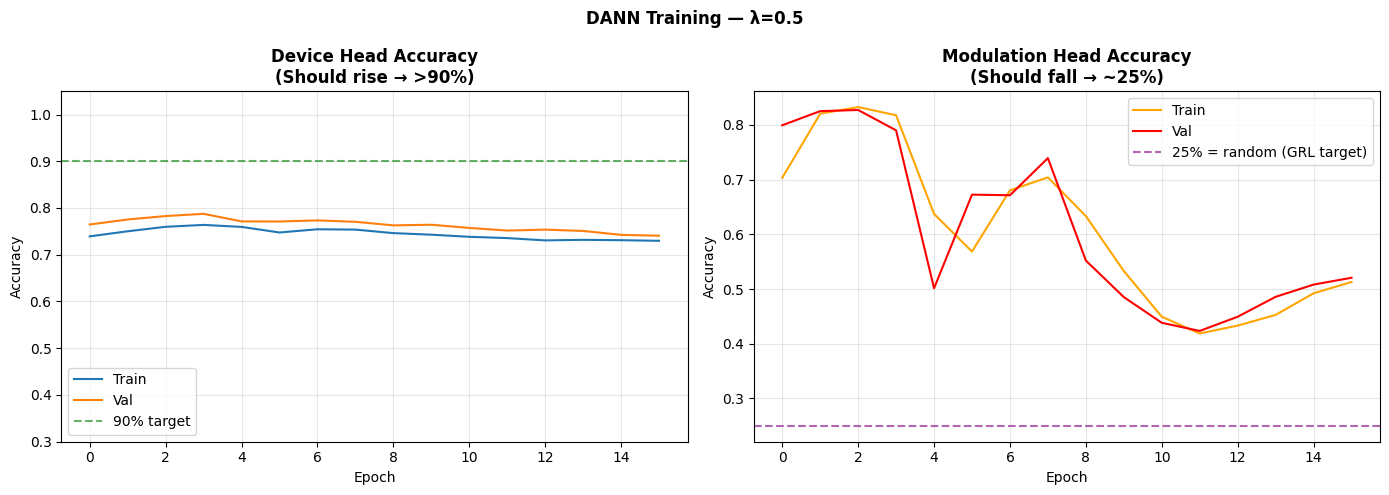

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['device_head_accuracy'],     label='Train')
axes[0].plot(history.history['val_device_head_accuracy'], label='Val')
axes[0].axhline(0.90, color='green', linestyle='--', alpha=0.6, label='90% target')
axes[0].set_title('Device Head Accuracy\n(Should rise → >90%)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([0.3,1.05])

axes[1].plot(history.history['mod_head_accuracy'],     label='Train', color='orange')
axes[1].plot(history.history['val_mod_head_accuracy'], label='Val',   color='red')
axes[1].axhline(0.25, color='purple', linestyle='--', alpha=0.6,
                label='25% = random (GRL target)')
axes[1].set_title('Modulation Head Accuracy\n(Should fall → ~25%)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'DANN Training — λ={LAMBDA_GRL}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR,'C3_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Embedding Extractor + OC-SVM (Fixes 1 + 2)

**Fix 1:** Grid search over nu to find best TAR at FAR ≤ 5%  
**Fix 2:** ROC-sweep calibration — finds threshold that maximises TAR while keeping FAR ≤ 5%

In [13]:
# Build embedding extractor
embedding_model = keras.Model(
    inputs=dann.input,
    outputs=dann.get_layer('embedding').output,
    name='dann_embedding'
)
embedding_model.trainable = False
print(f'Embedding: {embedding_model.output.shape}')

# Extract DEV01 embeddings for OC-SVM training
print('\nExtracting DEV01 embeddings...')
emb_parts = []
for mod in MODULATIONS:
    for sess in SESSIONS:
        for tag in AUG_TAGS:
            X, y = load_npy(sess, mod, tag)
            X01  = X[y == 0][:WINDOWS_CAP]
            emb  = embedding_model.predict(X01, batch_size=1024, verbose=0)
            emb_parts.append(emb)
            del X, y, X01, emb; gc.collect()
    print(f'  {mod}: done')

all_emb = np.concatenate(emb_parts)
del emb_parts; gc.collect()
print(f'Total DEV01 embeddings: {all_emb.shape}')

scaler = StandardScaler()
emb_scaled = scaler.fit_transform(all_emb)
del all_emb; gc.collect()

# FIX 1 — Grid search nu
SVM_CAP = min(50000, len(emb_scaled))
idx_svm = np.random.choice(len(emb_scaled), SVM_CAP, replace=False)
emb_svm_tr, emb_svm_val = train_test_split(
    emb_scaled[idx_svm], test_size=0.2, random_state=RANDOM_SEED
)

print('\nGrid searching nu...')
best_nu, best_tar_val = 0.1, 0.0
for nu_try in [0.01, 0.05, 0.1, 0.2, 0.3]:
    svm_try = OneClassSVM(kernel='rbf', nu=nu_try, gamma='scale')
    svm_try.fit(emb_svm_tr)
    scores_val = svm_try.decision_function(emb_svm_val)
    tar_val    = np.mean(scores_val >= 0) * 100
    print(f'  nu={nu_try}: TAR={tar_val:.1f}%')
    if tar_val > best_tar_val:
        best_tar_val, best_nu = tar_val, nu_try

print(f'\nBest nu: {best_nu}  (TAR={best_tar_val:.1f}%)')
ocsvm = OneClassSVM(kernel='rbf', nu=best_nu, gamma='scale')
ocsvm.fit(emb_scaled[idx_svm])
del emb_svm_tr, emb_svm_val; gc.collect()

# FIX 2 — ROC-sweep threshold calibration on BPSK S1 clean
print('\nCalibrating threshold via ROC sweep (FAR ≤ 5%)...')
X_cal, y_cal = load_npy('S1', 'BPSK', 'clean')
e01_cal = scaler.transform(
    embedding_model.predict(X_cal[y_cal==0][:3000], batch_size=1024, verbose=0))
e02_cal = scaler.transform(
    embedding_model.predict(X_cal[y_cal==1][:3000], batch_size=1024, verbose=0))
s01 = ocsvm.decision_function(e01_cal)
s02 = ocsvm.decision_function(e02_cal)

# Sweep all thresholds — find highest TAR where FAR ≤ 5%
thresholds = np.percentile(np.concatenate([s01, s02]), np.arange(0, 100, 0.5))
best_threshold, best_tar_sr2 = 0.0, 0.0
for t in thresholds:
    tar_t = np.mean(s01 >= t) * 100
    far_t = np.mean(s02 >= t) * 100
    if far_t <= 5.0 and tar_t > best_tar_sr2:
        best_tar_sr2   = tar_t
        best_threshold = t

threshold = best_threshold
print(f'Calibrated threshold : {threshold:.4f}')
print(f'TAR @ SR-2 threshold : {best_tar_sr2:.2f}%')
print(f'FAR @ SR-2 threshold : {np.mean(s02 >= threshold)*100:.2f}%  (≤5%)')

results_c3['best_nu'] = best_nu
results_c3['threshold'] = float(threshold)
results_c3['calibration_tar'] = float(best_tar_sr2)
del X_cal, y_cal, e01_cal, e02_cal; gc.collect()

Embedding: (None, 64)

Extracting DEV01 embeddings...
  BPSK: done
  QPSK: done
  GFSK: done
  OOK: done
Total DEV01 embeddings: (120000, 64)

Grid searching nu...
  nu=0.01: TAR=98.9%
  nu=0.05: TAR=95.1%
  nu=0.1: TAR=89.8%
  nu=0.2: TAR=79.3%
  nu=0.3: TAR=69.2%

Best nu: 0.01  (TAR=98.9%)

Calibrating threshold via ROC sweep (FAR ≤ 5%)...
Calibrated threshold : 3.9169
TAR @ SR-2 threshold : 55.00%
FAR @ SR-2 threshold : 5.00%  (≤5%)


566

## Section 8 — TAR/FAR per Modulation per SNR

**Core proof:** Consistent TAR/FAR across all 4 modulations = DANN learned
hardware fingerprint, not modulation-specific patterns.

In [14]:
def snr_tag_str(snr_level):
    return 'clean' if snr_level is None else f'SNR{snr_level}'


def evaluate(mod, snr_level):
    tag = snr_tag_str(snr_level)
    try:
        X, y = load_npy('S2', mod, tag)
    except FileNotFoundError:
        return None, None
    X01 = X[y==0]; X02 = X[y==1]
    if len(X01)==0 or len(X02)==0:
        return None, None
    e01 = scaler.transform(embedding_model.predict(X01, batch_size=1024, verbose=0))
    e02 = scaler.transform(embedding_model.predict(X02, batch_size=1024, verbose=0))
    tar = np.mean(ocsvm.decision_function(e01) >= threshold) * 100
    far = np.mean(ocsvm.decision_function(e02) >= threshold) * 100
    del X, y, X01, X02, e01, e02; gc.collect()
    return tar, far


tar_res = {m: {} for m in MODULATIONS}
far_res = {m: {} for m in MODULATIONS}

print('Evaluating DANN OC-SVM (S2 held-out)...')
for mod in MODULATIONS:
    for snr, label in zip(EVAL_SNRS, SNR_LABELS):
        tar, far = evaluate(mod, snr)
        tar_res[mod][label] = tar
        far_res[mod][label] = far
    print(f'  {mod}: done')

print('\nTAR (True Accept Rate):')
hdr = f"  {'Mod':<6}" + ''.join(f'{l:>12}' for l in SNR_LABELS)
print(hdr); print('  '+'-'*(6+12*len(SNR_LABELS)))
for m in MODULATIONS:
    row = f'  {m:<6}'
    for l in SNR_LABELS:
        v = tar_res[m][l]
        row += f'{v:>11.2f}%' if v is not None else f'{"N/A":>12}'
    print(row)

print('\nFAR (target ≤ 5%):')
print(hdr); print('  '+'-'*(6+12*len(SNR_LABELS)))
for m in MODULATIONS:
    row = f'  {m:<6}'
    for l in SNR_LABELS:
        v = far_res[m][l]
        row += f'{v:>11.2f}%' if v is not None else f'{"N/A":>12}'
    print(row)

results_c3['tar'] = tar_res
results_c3['far'] = far_res

Evaluating DANN OC-SVM (S2 held-out)...
  BPSK: done
  QPSK: done
  GFSK: done
  OOK: done

TAR (True Accept Rate):
  Mod          Clean       SNR20       SNR10        SNR0
  ------------------------------------------------------
  BPSK        41.02%      41.30%      43.04%      58.38%
  QPSK        41.71%      42.10%      45.09%      58.84%
  GFSK        66.86%      66.99%      67.41%      69.93%
  OOK         78.57%      78.69%      79.21%      82.16%

FAR (target ≤ 5%):
  Mod          Clean       SNR20       SNR10        SNR0
  ------------------------------------------------------
  BPSK         0.01%       0.02%       0.20%       6.01%
  QPSK        19.07%      19.03%      18.69%      16.80%
  GFSK        21.66%      21.63%      21.66%      25.37%
  OOK         78.76%      78.78%      79.27%      81.44%


## Section 9 — Heatmaps + ROC Curve

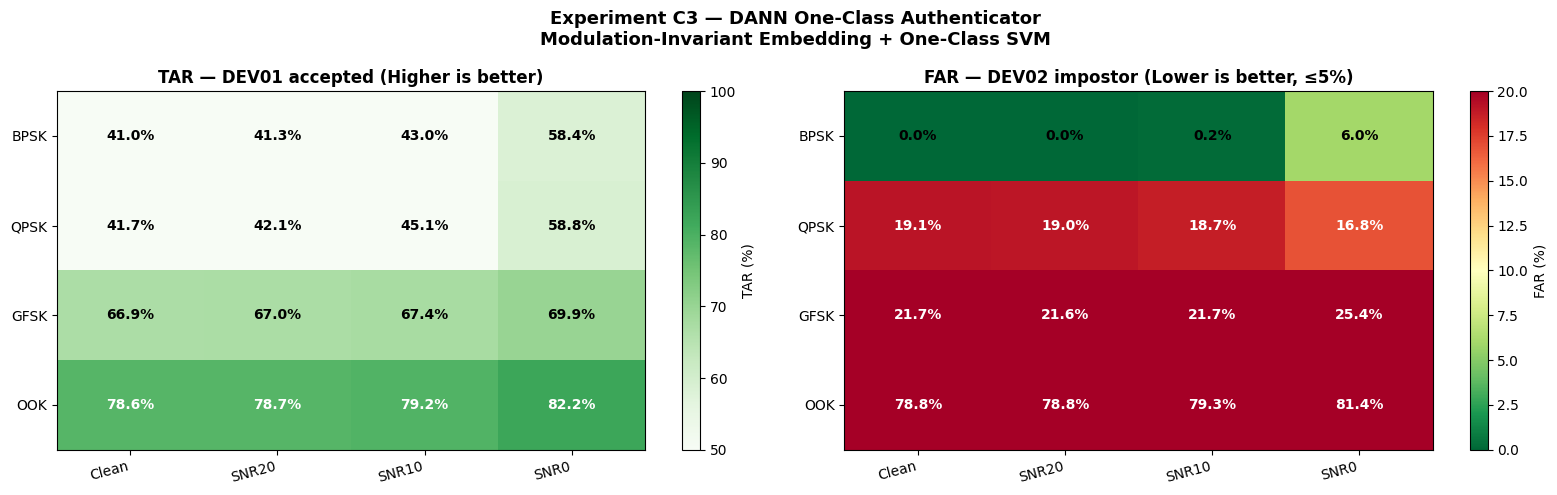

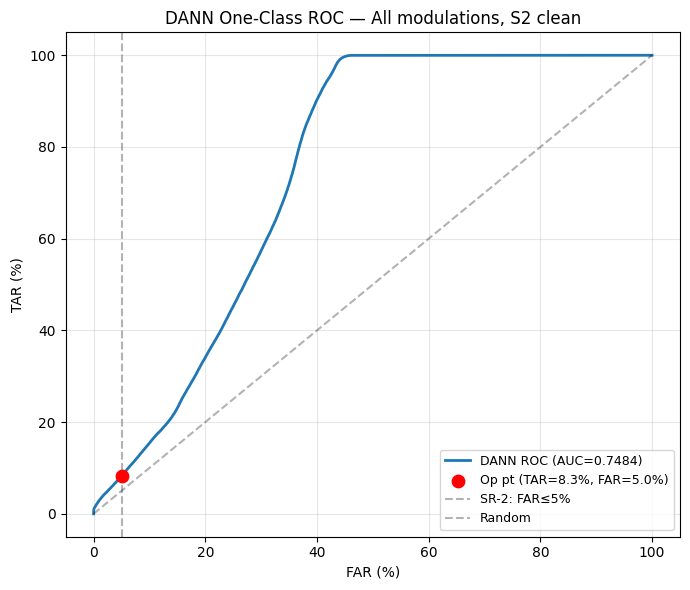

AUC: 0.7484  |  TAR @ FAR5%: 8.3%


In [15]:
# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
tar_mat = np.array([[tar_res[m][l] or 0 for l in SNR_LABELS] for m in MODULATIONS])
far_mat = np.array([[far_res[m][l] or 0 for l in SNR_LABELS] for m in MODULATIONS])

im1 = axes[0].imshow(tar_mat, cmap='Greens', vmin=50, vmax=100, aspect='auto')
axes[0].set_xticks(range(len(SNR_LABELS)))
axes[0].set_xticklabels(SNR_LABELS, rotation=15, ha='right')
axes[0].set_yticks(range(4)); axes[0].set_yticklabels(MODULATIONS)
axes[0].set_title('TAR — DEV01 accepted (Higher is better)', fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='TAR (%)')
for i in range(4):
    for j in range(len(SNR_LABELS)):
        v = tar_mat[i,j]
        axes[0].text(j,i,f'{v:.1f}%',ha='center',va='center',
                     fontweight='bold',fontsize=10,color='white' if v>75 else 'black')

im2 = axes[1].imshow(far_mat, cmap='RdYlGn_r', vmin=0, vmax=20, aspect='auto')
axes[1].set_xticks(range(len(SNR_LABELS)))
axes[1].set_xticklabels(SNR_LABELS, rotation=15, ha='right')
axes[1].set_yticks(range(4)); axes[1].set_yticklabels(MODULATIONS)
axes[1].set_title('FAR — DEV02 impostor (Lower is better, ≤5%)', fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='FAR (%)')
for i in range(4):
    for j in range(len(SNR_LABELS)):
        v = far_mat[i,j]
        axes[1].text(j,i,f'{v:.1f}%',ha='center',va='center',
                     fontweight='bold',fontsize=10,color='white' if v>10 else 'black')

fig.suptitle('Experiment C3 — DANN One-Class Authenticator\nModulation-Invariant Embedding + One-Class SVM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR,'C3_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# ROC curve
all_s01, all_s02 = [], []
for mod in MODULATIONS:
    X, y = load_npy('S2', mod, 'clean')
    e01 = scaler.transform(embedding_model.predict(X[y==0], batch_size=1024, verbose=0))
    e02 = scaler.transform(embedding_model.predict(X[y==1], batch_size=1024, verbose=0))
    all_s01.extend(ocsvm.decision_function(e01).tolist())
    all_s02.extend(ocsvm.decision_function(e02).tolist())
    del X, y, e01, e02; gc.collect()

scores = np.array(all_s01+all_s02)
labels = np.array([1]*len(all_s01)+[0]*len(all_s02))
fpr, tpr, _ = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)
op_idx  = np.argmin(np.abs(fpr - TARGET_FAR))
results_c3['auc']    = float(roc_auc)
results_c3['op_tar'] = float(tpr[op_idx]*100)
results_c3['op_far'] = float(fpr[op_idx]*100)

fig2, ax = plt.subplots(figsize=(7,6))
ax.plot(fpr*100, tpr*100, lw=2, label=f'DANN ROC (AUC={roc_auc:.4f})')
ax.scatter([fpr[op_idx]*100],[tpr[op_idx]*100],color='red',s=80,zorder=5,
           label=f'Op pt (TAR={tpr[op_idx]*100:.1f}%, FAR={fpr[op_idx]*100:.1f}%)')
ax.axvline(5,color='gray',linestyle='--',alpha=0.6,label='SR-2: FAR≤5%')
ax.plot([0,100],[0,100],'k--',alpha=0.3,label='Random')
ax.set_xlabel('FAR (%)'); ax.set_ylabel('TAR (%)')
ax.set_title('DANN One-Class ROC — All modulations, S2 clean')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR,'C3_roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC: {roc_auc:.4f}  |  TAR @ FAR5%: {tpr[op_idx]*100:.1f}%')

## Section 10 — Save Results + Final Summary

In [16]:
def make_serializable(obj):
    if isinstance(obj, (np.float32, np.float64)): return float(obj)
    if isinstance(obj, (np.int32, np.int64)):     return int(obj)
    if isinstance(obj, np.ndarray):               return obj.tolist()
    raise TypeError(f'Not serializable: {type(obj)}')

json_path = os.path.join(MODEL_DIR, 'experiment_C3_results.json')
with open(json_path, 'w') as f:
    json.dump(results_c3, f, indent=2, default=make_serializable)
print(f'Saved: {json_path}')

print('\n' + '='*65)
print('EXPERIMENT C3 — DANN ONE-CLASS AUTHENTICATOR SUMMARY')
print('='*65)
print(f'AUC                    : {results_c3["auc"]:.4f}')
print(f'TAR @ FAR≤5%           : {results_c3["op_tar"]:.1f}%')
print(f'Best OC-SVM nu         : {results_c3["best_nu"]}')
print(f'Calibration TAR        : {results_c3["calibration_tar"]:.2f}%')
print(f'DANN device acc (val)  : {final_dev_acc:.4f}')
print(f'DANN mod acc (val)     : {final_mod_acc:.4f}  (target ≈ 0.25)')
print()
print(f'  {"Mod":<6} {"TAR Clean":>12} {"FAR Clean":>12} {"SR-2 ≤5%":>10}')
print('  ' + '-'*44)
for m in MODULATIONS:
    t  = tar_res[m].get('Clean') or tar_res[m].get(SNR_LABELS[0])
    f_ = far_res[m].get('Clean') or far_res[m].get(SNR_LABELS[0])
    sr2 = '✅' if f_ is not None and f_ <= 5 else '❌'
    if t is not None:
        print(f'  {m:<6} {t:>11.2f}% {f_:>11.2f}%  {sr2:>8}')
print('='*65)

# GRL diagnostic
if final_mod_acc <= 0.35:
    print('✅ GRL working — modulation accuracy near random')
elif final_mod_acc <= 0.60:
    print('⚠️  GRL partially working — consider λ=1.0 for stronger effect')
else:
    print('❌ GRL not effective — mod accuracy still high')
    print('   → Rerun with LAMBDA_GRL = 1.0')
print('\nExperiment C3 complete.')

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentC3_DANN/experiment_C3_results.json

EXPERIMENT C3 — DANN ONE-CLASS AUTHENTICATOR SUMMARY
AUC                    : 0.7484
TAR @ FAR≤5%           : 8.3%
Best OC-SVM nu         : 0.01
Calibration TAR        : 55.00%
DANN device acc (val)  : 0.7875
DANN mod acc (val)     : 0.5206  (target ≈ 0.25)

  Mod       TAR Clean    FAR Clean   SR-2 ≤5%
  --------------------------------------------
  BPSK         41.02%        0.01%         ✅
  QPSK         41.71%       19.07%         ❌
  GFSK         66.86%       21.66%         ❌
  OOK          78.57%       78.76%         ❌
⚠️  GRL partially working — consider λ=1.0 for stronger effect

Experiment C3 complete.


In [17]:
# ── Section 11: Per-Modulation OC-SVM on DANN Embeddings ──────────────────
print('Per-Modulation DANN OC-SVM — using already-trained DANN backbone')
print('No retraining — reusing embedding_model, load_npy, WINDOWS_CAP from memory')
print()

svms_per_mod       = {}
scalers_per_mod    = {}
thresholds_per_mod = {}

for mod in MODULATIONS:
    print(f'--- {mod} ---')
    # Collect DEV01 DANN embeddings for this modulation only
    parts = []
    for sess in SESSIONS:
        for tag in AUG_TAGS:
            X, y = load_npy(sess, mod, tag)
            X01  = X[y == 0][:WINDOWS_CAP]
            emb  = embedding_model.predict(X01, batch_size=1024, verbose=0)
            parts.append(emb)
            del X, y, X01, emb
    emb_mod = np.concatenate(parts)
    del parts; gc.collect()

    # Scale
    sc = StandardScaler()
    emb_scaled_mod = sc.fit_transform(emb_mod)

    # Grid search nu
    emb_tr, emb_val = train_test_split(
        emb_scaled_mod, test_size=0.2, random_state=RANDOM_SEED)
    best_nu, best_tar = 0.1, 0.0
    for nu_try in [0.01, 0.05, 0.1, 0.2, 0.3]:
        svm_try = OneClassSVM(kernel='rbf', nu=nu_try, gamma='scale')
        svm_try.fit(emb_tr)
        tar_v = np.mean(svm_try.decision_function(emb_val) >= 0) * 100
        if tar_v > best_tar:
            best_tar, best_nu = tar_v, nu_try

    svm_mod = OneClassSVM(kernel='rbf', nu=best_nu, gamma='scale')
    svm_mod.fit(emb_scaled_mod)

    # Calibrate threshold at FAR ≤ 5% using S1 calibration data
    X_cal, y_cal = load_npy('S1', mod, 'clean')
    e01 = sc.transform(embedding_model.predict(
          X_cal[y_cal==0][:2000], batch_size=1024, verbose=0))
    e02 = sc.transform(embedding_model.predict(
          X_cal[y_cal==1][:2000], batch_size=1024, verbose=0))
    s01 = svm_mod.decision_function(e01)
    s02 = svm_mod.decision_function(e02)

    best_t, best_tar_cal = 0.0, 0.0
    for t in np.percentile(np.concatenate([s01, s02]), np.arange(0, 100, 0.5)):
        far_t = np.mean(s02 >= t) * 100
        tar_t = np.mean(s01 >= t) * 100
        if far_t <= 5.0 and tar_t > best_tar_cal:
            best_tar_cal, best_t = tar_t, t

    svms_per_mod[mod]       = svm_mod
    scalers_per_mod[mod]    = sc
    thresholds_per_mod[mod] = best_t
    print(f'  Best nu={best_nu} | Calibration TAR={best_tar_cal:.1f}% @ FAR≤5%')
    del emb_mod, emb_scaled_mod, X_cal, y_cal, e01, e02; gc.collect()


# ── Evaluate per modulation per SNR ───────────────────────────────────────
print('\n=== Per-Modulation DANN OC-SVM — Full Evaluation (S2 held-out) ===\n')

tar_pm = {m: {} for m in MODULATIONS}
far_pm = {m: {} for m in MODULATIONS}

for mod in MODULATIONS:
    for snr, label in zip(EVAL_SNRS, SNR_LABELS):
        tag = snr_tag_str(snr)
        try:
            X, y = load_npy('S2', mod, tag)
        except FileNotFoundError:
            tar_pm[mod][label] = None
            far_pm[mod][label] = None
            continue
        e01 = scalers_per_mod[mod].transform(
              embedding_model.predict(X[y==0], batch_size=1024, verbose=0))
        e02 = scalers_per_mod[mod].transform(
              embedding_model.predict(X[y==1], batch_size=1024, verbose=0))
        t   = thresholds_per_mod[mod]
        tar_pm[mod][label] = np.mean(
            svms_per_mod[mod].decision_function(e01) >= t) * 100
        far_pm[mod][label] = np.mean(
            svms_per_mod[mod].decision_function(e02) >= t) * 100
        del X, y, e01, e02; gc.collect()

# Print TAR table
print('TAR (True Accept Rate):')
hdr = f"  {'Mod':<6}" + ''.join(f'{l:>12}' for l in SNR_LABELS)
print(hdr); print('  ' + '-'*(6+12*len(SNR_LABELS)))
for m in MODULATIONS:
    row = f'  {m:<6}'
    for l in SNR_LABELS:
        v = tar_pm[m][l]
        row += f'{v:>11.2f}%' if v is not None else f'{"N/A":>12}'
    print(row)

print()
print('FAR (target ≤ 5%):')
print(hdr); print('  ' + '-'*(6+12*len(SNR_LABELS)))
for m in MODULATIONS:
    row = f'  {m:<6}'
    for l in SNR_LABELS:
        v = far_pm[m][l]
        row += f'{v:>11.2f}%' if v is not None else f'{"N/A":>12}'
    print(row)

# Summary
print('\n=== FINAL SUMMARY — Per-Modulation DANN OC-SVM ===')
print(f'  {"Mod":<6} {"TAR Clean":>12} {"FAR Clean":>12} {"SR-2 ≤5%":>10}')
print('  ' + '-'*44)
for m in MODULATIONS:
    t  = tar_pm[m].get(SNR_LABELS[0])
    f_ = far_pm[m].get(SNR_LABELS[0])
    sr2 = '✅' if f_ is not None and f_ <= 5.0 else '❌'
    if t is not None:
        print(f'  {m:<6} {t:>11.2f}% {f_:>11.2f}%  {sr2:>8}')

# Save to JSON
results_c3['per_mod_svm'] = {
    'tar': tar_pm,
    'far': far_pm
}
json_path = os.path.join(MODEL_DIR, 'experiment_C3_results.json')
with open(json_path, 'w') as f:
    json.dump(results_c3, f, indent=2, default=make_serializable)
print(f'\nResults updated: {json_path}')
print('\nExperiment C — COMPLETE. Moving to Chapter 4.')

Per-Modulation DANN OC-SVM — using already-trained DANN backbone
No retraining — reusing embedding_model, load_npy, WINDOWS_CAP from memory

--- BPSK ---
  Best nu=0.01 | Calibration TAR=66.2% @ FAR≤5%
--- QPSK ---
  Best nu=0.01 | Calibration TAR=68.1% @ FAR≤5%
--- GFSK ---
  Best nu=0.01 | Calibration TAR=12.2% @ FAR≤5%
--- OOK ---
  Best nu=0.01 | Calibration TAR=6.0% @ FAR≤5%

=== Per-Modulation DANN OC-SVM — Full Evaluation (S2 held-out) ===

TAR (True Accept Rate):
  Mod          Clean       SNR20       SNR10        SNR0
  ------------------------------------------------------
  BPSK        76.87%      77.14%      79.29%      88.04%
  QPSK        57.38%      57.74%      61.15%      72.24%
  GFSK         4.36%       4.44%       5.23%      10.12%
  OOK          2.60%       2.64%       2.97%       4.21%

FAR (target ≤ 5%):
  Mod          Clean       SNR20       SNR10        SNR0
  ------------------------------------------------------
  BPSK         0.02%       0.03%       0.10%    